### Lets start with basic single feature for polynomial regression, where data is curve in nature to output

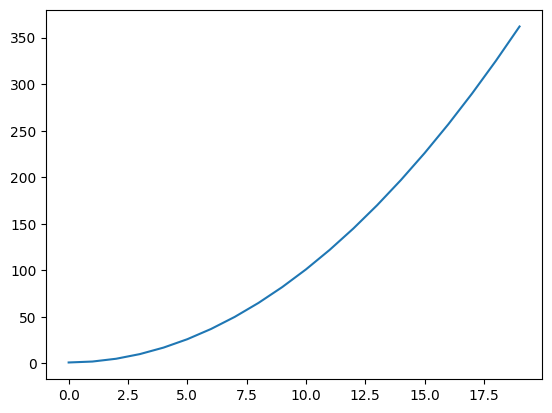

In [49]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(20)
y = x**2 + 1
plt.plot(x, y)

lets take normalization find if straight line equation fits into it

In [50]:
def compute_cost(x,y,w,b):
    if(len(x.shape)>1):
        m,n = x.shape #m samples, n features
    else:
        m = len(x)

    cost = 0
    for i in range(m):
        error = np.dot(x[i],w)+b-y[i] #dot product
        cost = cost+error**2
    return cost/(2*m)

def gradient(x,y,w,b):
    if(len(x.shape)>1):
        m,n = x.shape #m samples, n features
        dw = np.zeros((n,))
    else:
        m = len(x)
        dw = np.zeros((1,))
    db= 0.

    for i in range(m):
        error = np.dot(w,x[i])+b-y[i] #dot product
        dw = dw+(error*x[i])
        db = db+error
    return dw/m,db/m

def r_squared(y, y_pred):
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2))

def zscore(x):
    mu = np.mean(x,axis=0) #mean
    sigma = np.std(x,axis=0) #standard deviation
    x_norm = (x-mu)/sigma
    return x_norm,mu,sigma

In [51]:
x_norm,mu,sigma = zscore(x)
alpha = 0.1
if(len(x.shape)>1):
    m,n = x.shape #m samples, n features
    w= np.zeros((n,))
else:
    w= np.zeros(1)
b = 0.

for i in range(10000):
    if(i%1000 == 0):
        print(f"Cost of {i} iteration is {compute_cost(x_norm,y,w,b )}")
    dw,db = gradient(x_norm,y,w,b )
    w= w-alpha*dw
    b=b-alpha*db


Cost of 0 iteration is [14190.65]
Cost of 1000 iteration is [438.9]
Cost of 2000 iteration is [438.9]
Cost of 3000 iteration is [438.9]
Cost of 4000 iteration is [438.9]
Cost of 5000 iteration is [438.9]
Cost of 6000 iteration is [438.9]
Cost of 7000 iteration is [438.9]
Cost of 8000 iteration is [438.9]
Cost of 9000 iteration is [438.9]


Now lets add $x^2$

In [52]:
x_fe = np.c_[x_norm,x_norm**2]
#fe - feature engineering

alpha = 0.1
if(len(x_fe.shape)>1):
    m,n = x_fe.shape #m samples, n features
    w_fe= np.zeros((n,))
else:
    w_fe= np.zeros(1)
b_fe = 0.

for i in range(10000):
    if(i%1000 == 0):
        print(f"Cost of {i} iteration is {compute_cost(x_fe,y,w_fe,b_fe )}")
    dw_fe,db_fe = gradient(x_fe,y,w_fe,b_fe )
    w_fe= w_fe-alpha*dw_fe
    b_fe  = b_fe-alpha*db_fe

Cost of 0 iteration is 14190.65
Cost of 1000 iteration is 3.054595642760593e-26
Cost of 2000 iteration is 9.452446910720252e-27
Cost of 3000 iteration is 9.452446910720252e-27
Cost of 4000 iteration is 9.452446910720252e-27
Cost of 5000 iteration is 9.452446910720252e-27
Cost of 6000 iteration is 9.452446910720252e-27
Cost of 7000 iteration is 9.452446910720252e-27
Cost of 8000 iteration is 9.452446910720252e-27
Cost of 9000 iteration is 9.452446910720252e-27


See how cost function reduces, lets plot orginal x and straight line and polynomial equation line looks like

In [53]:
y_prediction_straight = x_norm * w + b #single feature
y_prediction_ploy = x_fe @ w_fe + b_fe #matrix multiplication because of 2 features

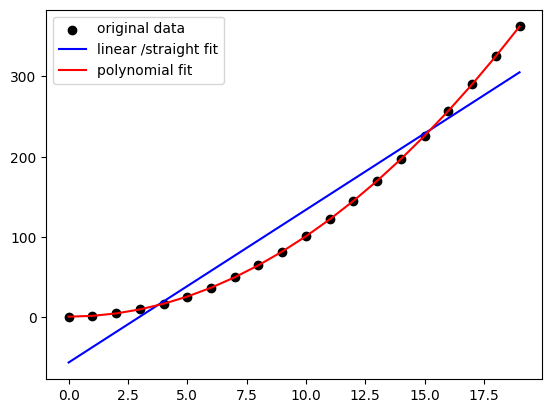

In [54]:
plt.scatter(x, y, color='black', label='original data')
plt.plot(x, y_prediction_straight, color='blue', label='linear /straight fit')
plt.plot(x, y_prediction_ploy, color='red', label='polynomial fit')
plt.legend()
plt.show()

In [55]:
print("Linear model:")
print("  R2:", r_squared(y, y_prediction_straight))
print("  MAE:", mae(y, y_prediction_straight))
print("  RMSE:", rmse(y, y_prediction_straight))

print("poly model:")
print("  R2:", r_squared(y, y_prediction_ploy))
print("  MAE:", mae(y, y_prediction_ploy))
print("  RMSE:", rmse(y, y_prediction_ploy))

Linear model:
  R2: 0.931853381517811
  MAE: 25.599999999999984
  RMSE: 29.627689751312026
poly model:
  R2: 1.0
  MAE: 1.2185807918285717e-13
  RMSE: 1.3830053164160555e-13


### Another dataset, but from seaborn

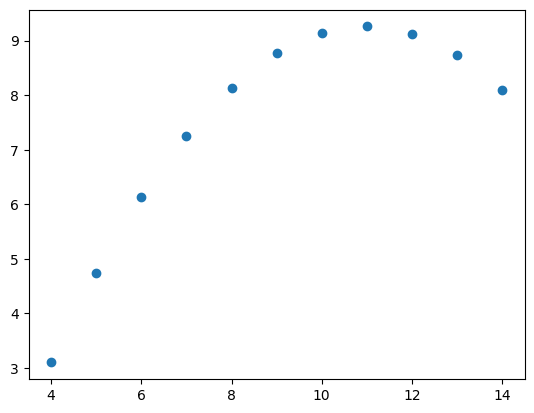

In [56]:
import seaborn as sns
df = sns.load_dataset("anscombe")
data= df[df["dataset"] == "II"]  # this subset is a perfect quadratic curve
x = data['x'].to_numpy()
y = data['y'].to_numpy()

sort_idx = np.argsort(x)

x = x[sort_idx]
y = y[sort_idx]

plt.scatter(x,y)


Lets compare with linear and poly equations

In [57]:
x_norm,mu,sigma = zscore(x)

In [58]:
#linear
alpha = 0.1
if(len(x.shape)>1):
    m,n = x.shape #m samples, n features
    w= np.zeros((n,))
else:
    w= np.zeros(1)
b = 0.

for i in range(10000):
    if(i%1000 == 0):
        print(f"Cost of {i} iteration is {compute_cost(x_norm,y,w,b )}")
    dw,db = gradient(x_norm,y,w,b )
    w= w-alpha*dw



Cost of 0 iteration is [30.00801364]
Cost of 1000 iteration is [28.75801364]
Cost of 2000 iteration is [28.75801364]
Cost of 3000 iteration is [28.75801364]
Cost of 4000 iteration is [28.75801364]
Cost of 5000 iteration is [28.75801364]
Cost of 6000 iteration is [28.75801364]
Cost of 7000 iteration is [28.75801364]
Cost of 8000 iteration is [28.75801364]
Cost of 9000 iteration is [28.75801364]


In [59]:
#poly

x_fe = np.c_[x_norm,x_norm**2]
#fe - feature engineering

alpha = 0.1
if(len(x_fe.shape)>1):
    m,n = x_fe.shape #m samples, n features
    w_fe= np.zeros((n,))
else:
    w_fe= np.zeros(1)
b_fe = 0.

for i in range(10000):
    if(i%1000 == 0):
        print(f"Cost of {i} iteration is {compute_cost(x_fe,y,w_fe,b_fe )}")
    dw_fe,db_fe = gradient(x_fe,y,w_fe,b_fe )
    w_fe= w_fe-alpha*dw_fe
    b_fe  = b_fe-alpha*db_fe

Cost of 0 iteration is 30.00801363636364
Cost of 1000 iteration is 1.0171646535286165e-06
Cost of 2000 iteration is 1.0171646535279897e-06
Cost of 3000 iteration is 1.0171646535279897e-06
Cost of 4000 iteration is 1.0171646535279897e-06
Cost of 5000 iteration is 1.0171646535279897e-06
Cost of 6000 iteration is 1.0171646535279897e-06
Cost of 7000 iteration is 1.0171646535279897e-06
Cost of 8000 iteration is 1.0171646535279897e-06
Cost of 9000 iteration is 1.0171646535279897e-06


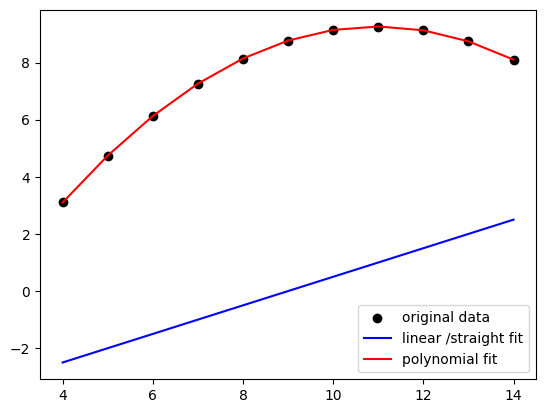

In [60]:
y_prediction_straight = x_norm * w + b #single feature
y_prediction_ploy = x_fe @ w_fe + b_fe #matrix multiplication because of 2 features

plt.scatter(x, y, color='black', label='original data')
plt.plot(x, y_prediction_straight, color='blue', label='linear /straight fit')
plt.plot(x, y_prediction_ploy, color='red', label='polynomial fit')
plt.legend()
plt.show()

Gradient descent will assign the weights to degree $x^2$, $x^3$, $x^4$ to fit to model

if we choose high degree it may over fit the data